In [1]:
pip install h5py matplotlib

In [2]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive to access your files
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define file paths (replace these with your actual paths in Google Drive)
geometry_file = '/content/drive/MyDrive/mintpy_output/location1/geometryGeo.h5'
timeseries_file = '/content/drive/MyDrive/mintpy_output/location1/timeseries_ERA5_demErr.h5'
coherence_file = '/content/drive/MyDrive/mintpy_output/location1/temporalCoherence.h5'  # Optional

# Load georeferencing data to find pixel coordinates
with h5py.File(geometry_file, 'r') as f:
    lat_grid = f['latitude'][:]  # 2D array of latitude values
    lon_grid = f['longitude'][:]  # 2D array of longitude values

# Your target coordinates
target_lat = 11.46676306
target_lon = 76.1362722

# Find the pixel (y, x) closest to your coordinates
diff_lat = np.abs(lat_grid - target_lat)
diff_lon = np.abs(lon_grid - target_lon)
total_diff = diff_lat + diff_lon
y, x = np.unravel_index(np.argmin(total_diff), lat_grid.shape)
print(f"Pixel coordinates found: y={y}, x={x}")

# Load the timeseries data
with h5py.File(timeseries_file, 'r') as f:
    dates = [date.decode('utf-8') for date in f['date'][:]]  # Dates as strings
    displacement = f['timeseries'][:, y, x]  # Displacement at the pixel

# Convert dates to datetime objects
dates = [datetime.strptime(date, '%Y%m%d') for date in dates]

# Define your date range
start_date = datetime(2023, 7, 19)
end_date = datetime(2024, 6, 25)

# Filter data for the specified date range
filtered_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]
filtered_dates = [dates[i] for i in filtered_indices]
filtered_displacement = displacement[filtered_indices]

# Convert displacement from meters to millimeters
filtered_displacement_mm = filtered_displacement * 1000

# Optional: Check temporal coherence for data reliability
try:
    with h5py.File(coherence_file, 'r') as f:
        coherence = f['temporalCoherence'][y, x]
    print(f"Temporal coherence: {coherence:.2f}")
    if coherence < 0.7:
        print("Warning: Low coherence. Data may be unreliable.")
except:
    print("Couldn’t load temporalCoherence.h5. Skipping coherence check.")

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(filtered_dates, filtered_displacement_mm, marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title(f'Land Deformation at Lat: {target_lat:.4f}, Lon: {target_lon:.4f}')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Optional: Save the plot to your Google Drive
plt.savefig('/content/drive/MyDrive/mintpy_output/location4/deformation_plot.png')
print("Plot saved to Google Drive as 'deformation_plot.png'")

# Display the plot
plt.show()

KeyError: "Unable to synchronously open object (object 'latitude' doesn't exist)"

In [4]:
from google.colab import drive
import h5py

# Mount Google Drive
drive.mount('/content/drive')

# List of HDF5 file paths to inspect (update these with your actual file paths)
file_paths = [
    '/content/drive/MyDrive/mintpy_output/location1/geometryGeo.h5', '/content/drive/MyDrive/mintpy_output/location1/timeseries_ERA5_demErr.h5', '/content/drive/MyDrive/mintpy_output/location1/temporalCoherence.h5']

# Function to recursively print the structure of an HDF5 file
def print_hdf5_structure(name, obj, indent=0):
    """
    Recursively prints the structure of an HDF5 file.
    - name: current name (key) in the file
    - obj: current object (group or dataset)
    - indent: indentation level for readability
    """
    if isinstance(obj, h5py.Group):
        print('  ' * indent + f"- Group: {name}")
        for key in obj.keys():
            print_hdf5_structure(key, obj[key], indent + 1)
    elif isinstance(obj, h5py.Dataset):
        print('  ' * indent + f"- Dataset: {name}")

# Inspect each file
for file_path in file_paths:
    print(f"\nInspecting file: {file_path}")
    try:
        with h5py.File(file_path, 'r') as f:
            print_hdf5_structure('/', f)
    except Exception as e:
        print(f"Error opening {file_path}: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Inspecting file: /content/drive/MyDrive/mintpy_output/location1/geometryGeo.h5
- Group: /
  - Dataset: azimuthAngle
  - Dataset: height
  - Dataset: incidenceAngle
  - Dataset: slantRangeDistance
  - Dataset: waterMask

Inspecting file: /content/drive/MyDrive/mintpy_output/location1/timeseries_ERA5_demErr.h5
- Group: /
  - Dataset: bperp
  - Dataset: date
  - Dataset: timeseries

Inspecting file: /content/drive/MyDrive/mintpy_output/location1/temporalCoherence.h5
- Group: /
  - Dataset: temporalCoherence


In [ ]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive (skip if already mounted)
drive.mount('/content/drive', force_remount=True)

# Define file paths
geometry_file = '/content/drive/MyDrive/mintpy_output/location1/geometryGeo.h5'
timeseries_file = '/content/drive/MyDrive/mintpy_output/location1/timeseries_ERA5_demErr.h5'
coherence_file = '/content/drive/MyDrive/mintpy_output/location1/temporalCoherence.h5'

# Target coordinates
target_lat = 11.46676306
target_lon = 76.1362722

# Function to calculate pixel coordinates
def get_pixel_coords(file, lat, lon):
    with h5py.File(file, 'r') as f:
        # Check for common MintPy attributes
        required_attrs = ['Y_FIRST', 'X_FIRST', 'Y_STEP', 'X_STEP', 'LENGTH', 'WIDTH']
        missing_attrs = [attr for attr in required_attrs if attr not in f.attrs]

        if missing_attrs:
            print("Missing attributes:", missing_attrs)
            print("Available attributes in geometryGeo.h5:")
            for attr_name, attr_value in f.attrs.items():
                print(f"- {attr_name}: {attr_value}")
            raise KeyError("Required georeferencing attributes not found. Please share the attributes printed above.")

        Y_FIRST = float(f.attrs['Y_FIRST'])
        X_FIRST = float(f.attrs['X_FIRST'])
        Y_STEP = float(f.attrs['Y_STEP'])
        X_STEP = float(f.attrs['X_STEP'])
        LENGTH = int(f.attrs['LENGTH'])
        WIDTH = int(f.attrs['WIDTH'])

        # Calculate pixel indices
        y = int((lat - Y_FIRST) / Y_STEP)
        x = int((lon - X_FIRST) / X_STEP)

        # Verify bounds
        if not (0 <= y < LENGTH and 0 <= x < WIDTH):
            raise ValueError(f"Coordinates (y={y}, x={x}) are outside data bounds (LENGTH={LENGTH}, WIDTH={WIDTH}).")

        return y, x

# Get pixel coordinates
try:
    y, x = get_pixel_coords(geometry_file, target_lat, target_lon)
    print(f"Pixel coordinates: y={y}, x={x}")
except Exception as e:
    print(f"Error: {e}")
    print("Please run the attribute inspection code separately if needed and share the output.")
    raise

# Load and process timeseries data
with h5py.File(timeseries_file, 'r') as f:
    dates = [date.decode('utf-8') for date in f['date'][:]]
    displacement = f['timeseries'][:, y, x]

# Convert dates to datetime
dates = [datetime.strptime(date, '%Y%m%d') for date in dates]

# Define date range
start_date = datetime(2023, 7, 19)
end_date = datetime(2024, 6, 25)

# Filter data
filtered_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]
filtered_dates = [dates[i] for i in filtered_indices]
filtered_displacement = displacement[filtered_indices]

# Convert displacement to mm
filtered_displacement_mm = filtered_displacement * 1000

# Optional: Check temporal coherence
try:
    with h5py.File(coherence_file, 'r') as f:
        coherence = f['temporalCoherence'][y, x]
    print(f"Temporal coherence: {coherence:.2f}")
    if coherence < 0.7:
        print("Warning: Low coherence. Data may be unreliable.")
except:
    print("Could not load temporalCoherence.h5. Skipping coherence check.")

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(filtered_dates, filtered_displacement_mm, marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title(f'Land Deformation at Lat: {target_lat:.4f}, Lon: {target_lon:.4f}')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mounted at /content/drive
Error: Coordinates (y=17487, x=-6156) are outside data bounds (LENGTH=2765, WIDTH=2072).
Please run the attribute inspection code separately if needed and share the output.


ValueError: Coordinates (y=17487, x=-6156) are outside data bounds (LENGTH=2765, WIDTH=2072).

In [8]:
import h5py

# Path to your geometry file
geometry_file = '/content/drive/MyDrive/mintpy_output/location2/geometryGeo.h5'

# Open the file and print all attributes
with h5py.File(geometry_file, 'r') as f:
    print("Attributes of geometryGeo.h5:")
    for attr_name, attr_value in f.attrs.items():
        print(f"- {attr_name}: {attr_value}")

Attributes of geometryGeo.h5:
- ALOOKS: 4
- ANTENNA_SIDE: -1
- AZIMUTH_PIXEL_SIZE: 56.4
- BANDS: 1
- CENTER_LINE_UTC: 42513.802129
- DATA_TYPE: float32
- EARTH_RADIUS: 6374459.7922
- EPSG: 4326
- FILE_LENGTH: 2809
- FILE_PATH: /home/jovyan/noney_sbas/S1AA_20210710T114831_20210722T114832_VVP012_INT80_G_weF_3931/S1AA_20210710T114831_20210722T114832_VVP012_INT80_G_weF_3931_dem.tif
- FILE_TYPE: geometry
- HEADING: -12.4637295
- HEIGHT: 698613.4128999999
- INTERLEAVE: BSQ
- LAT_REF1: 23.8513887952669
- LAT_REF2: 23.8513887952669
- LAT_REF3: 25.998419460182813
- LAT_REF4: 25.998419460182813
- LENGTH: 2809
- LON_REF1: 92.8335582160996
- LON_REF2: 95.68607457119614
- LON_REF3: 92.8335582160996
- LON_REF4: 95.68607457119614
- NO_DATA_VALUE: 0.0
- NoDataValue: 0.0
- ORBIT_DIRECTION: ASCENDING
- PLATFORM: Sen
- PROCESSOR: hyp3
- RANGE_PIXEL_SIZE: 46.0
- RLOOKS: 20
- STARTING_RANGE: 799006.2613
- WAVELENGTH: 0.055465764662349676
- WIDTH: 3732
- X_FIRST: 92.8335582160996
- X_STEP: 0.000764339859350

Mounted at /content/drive
Pixel coordinates: y=1518, x=859


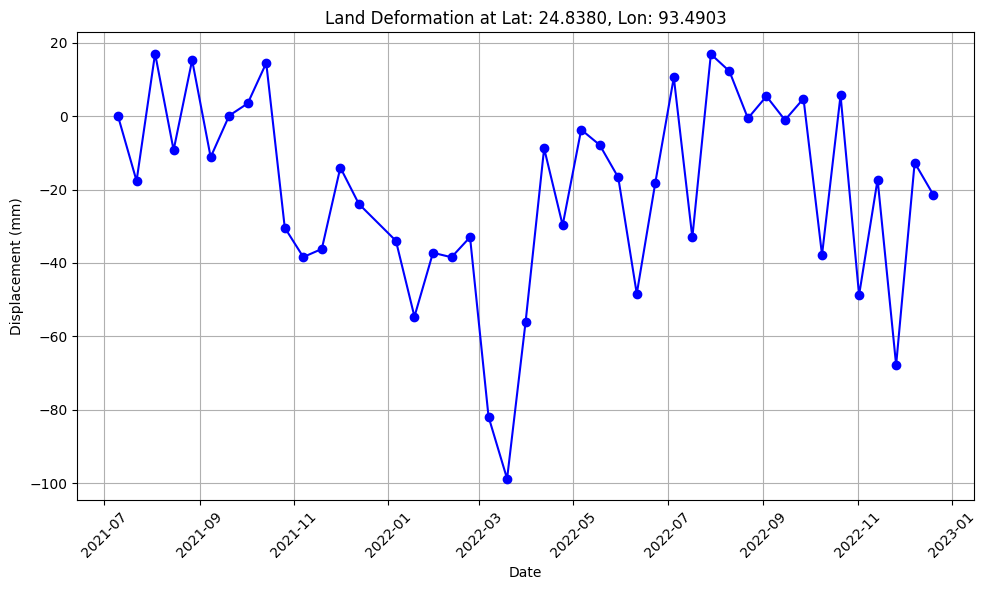

In [9]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
geometry_file = '/content/drive/MyDrive/mintpy_output/location2/geometryGeo.h5'
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'
coherence_file = '/content/drive/MyDrive/mintpy_output/location2/temporalCoherence.h5'

# Target coordinates
target_lat = 24.83804722
target_lon = 93.4902722

# Function to calculate pixel coordinates using geographic coordinates
def get_pixel_coords(file, lat, lon):
    with h5py.File(file, 'r') as f:
        X_FIRST = float(f.attrs['X_FIRST'])
        Y_FIRST = float(f.attrs['Y_FIRST'])
        X_STEP = float(f.attrs['X_STEP'])
        Y_STEP = float(f.attrs['Y_STEP'])
        LENGTH = int(f.attrs['LENGTH'])
        WIDTH = int(f.attrs['WIDTH'])

        # Calculate pixel indices using latitude and longitude directly
        x = int((lon - X_FIRST) / X_STEP)
        y = int((lat - Y_FIRST) / Y_STEP)

        # Check bounds
        if 0 <= x < WIDTH and 0 <= y < LENGTH:
            return y, x  # y is row, x is column
        else:
            raise ValueError(f"Coordinates (y={y}, x={x}) outside bounds (LENGTH={LENGTH}, WIDTH={WIDTH})")

# Get pixel coordinates
try:
    y, x = get_pixel_coords(geometry_file, target_lat, target_lon)
    print(f"Pixel coordinates: y={y}, x={x}")
except ValueError as e:
    print(e)
    raise

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    dates = [date.decode('utf-8') for date in f['date'][:]]
    displacement = f['timeseries'][:, y, x]

# Convert dates to datetime
dates = [datetime.strptime(date, '%Y%m%d') for date in dates]

# Define date range (optional; adjust as needed)
# If you want to filter dates, uncomment and set the range
# start_date = datetime(2023, 7, 19)
# end_date = datetime(2024, 6, 25)
# filtered_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]
# filtered_dates = [dates[i] for i in filtered_indices]
# filtered_displacement = displacement[filtered_indices]
# Plotting filtered data
# displacement_mm = filtered_displacement * 1000
# dates_to_plot = filtered_dates
# if not dates_to_plot:
#     print("No data in specified date range. Plotting all data instead.")
#     displacement_mm = displacement * 1000
#     dates_to_plot = dates
# else:
#     print(f"Plotting data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# For now, plot all data since no date range is specified
displacement_mm = displacement * 1000  # Convert meters to millimeters
dates_to_plot = dates

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates_to_plot, displacement_mm, marker='o', linestyle='-', color='b')
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title(f'Land Deformation at Lat: {target_lat:.4f}, Lon: {target_lon:.4f}')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mounted at /content/drive
Target pixel coordinates: y=1518, x=859
Nearby pixels (including target): [(1517, 858), (1517, 859), (1517, 860), (1518, 858), (1518, 859), (1518, 860), (1519, 858), (1519, 859), (1519, 860)]
Plot saved to Google Drive as 'deformation_nearby_pixels.png'


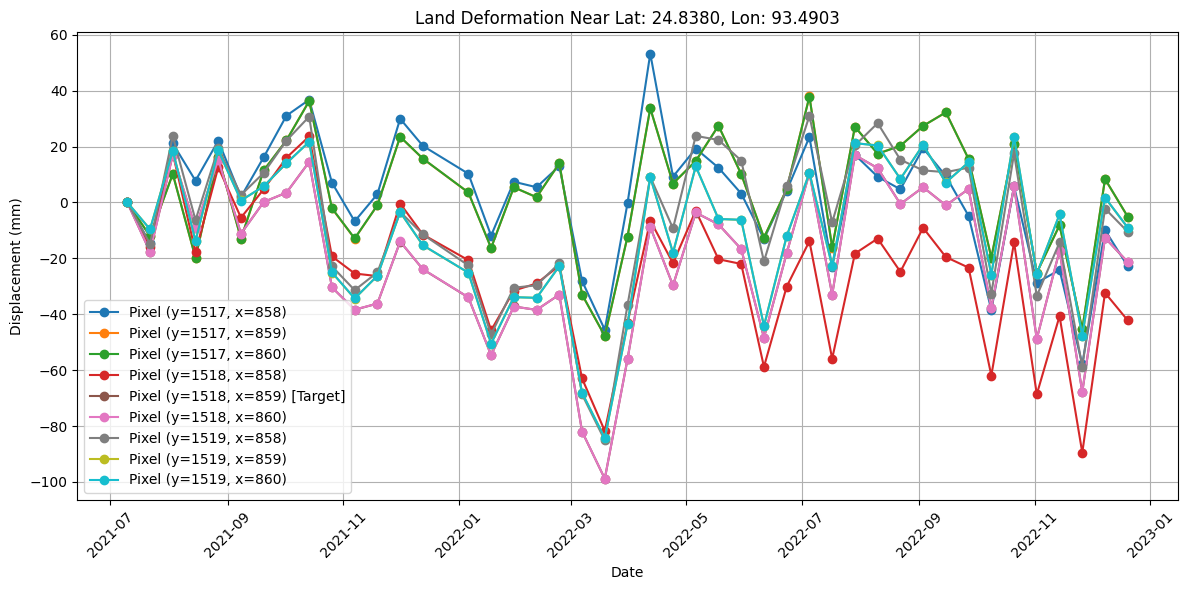

In [10]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
geometry_file = '/content/drive/MyDrive/mintpy_output/location2/geometryGeo.h5'
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Target coordinates
target_lat = 24.83804722
target_lon = 93.4902722

# Function to calculate pixel coordinates using geographic coordinates
def get_pixel_coords(file, lat, lon):
    with h5py.File(file, 'r') as f:
        X_FIRST = float(f.attrs['X_FIRST'])
        Y_FIRST = float(f.attrs['Y_FIRST'])
        X_STEP = float(f.attrs['X_STEP'])
        Y_STEP = float(f.attrs['Y_STEP'])
        LENGTH = int(f.attrs['LENGTH'])
        WIDTH = int(f.attrs['WIDTH'])

        # Calculate pixel indices
        x = int((lon - X_FIRST) / X_STEP)
        y = int((lat - Y_FIRST) / Y_STEP)

        # Check bounds
        if 0 <= x < WIDTH and 0 <= y < LENGTH:
            return y, x, LENGTH, WIDTH
        else:
            raise ValueError(f"Coordinates (y={y}, x={x}) outside bounds (LENGTH={LENGTH}, WIDTH={WIDTH})")

# Function to get nearby pixels within a radius
def get_nearby_pixels(y, x, radius, length, width):
    nearby_pixels = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            new_y, new_x = y + dy, x + dx
            if 0 <= new_y < length and 0 <= new_x < width:
                nearby_pixels.append((new_y, new_x))
    return nearby_pixels

# Get pixel coordinates
try:
    y, x, LENGTH, WIDTH = get_pixel_coords(geometry_file, target_lat, target_lon)
    print(f"Target pixel coordinates: y={y}, x={x}")
except ValueError as e:
    print(e)
    raise

# Find nearby pixels (radius of 1 pixel, so 3x3 grid)
radius = 1
nearby_pixels = get_nearby_pixels(y, x, radius, LENGTH, WIDTH)
print(f"Nearby pixels (including target): {nearby_pixels}")

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    dates = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert dates to datetime
dates = [datetime.strptime(date, '%Y%m%d') for date in dates]

# Optional: Define date range (uncomment and adjust as needed)
# start_date = datetime(2023, 7, 19)
# end_date = datetime(2024, 6, 25)
# filtered_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]
# filtered_dates = [dates[i] for i in filtered_indices]
# if not filtered_dates:
#     print(f"No data available between {start_date.strftime('%Y-%m-%d')} and {end_date.strftime('%Y-%m-%d')}.")
#     print("Plotting all available data instead.")
#     filtered_dates = dates
#     filtered_indices = list(range(len(dates)))
# else:
#     print(f"Plotting data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# For now, plot all data
filtered_dates = dates
filtered_indices = list(range(len(dates)))

# Plot setup
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(nearby_pixels)))  # Distinct colors for each pixel

# Plot deformation for each pixel
for idx, (pixel_y, pixel_x) in enumerate(nearby_pixels):
    # Extract displacement for this pixel
    displacement = timeseries_data[:, pixel_y, pixel_x]
    filtered_displacement = displacement[filtered_indices]
    # Convert to millimeters
    displacement_mm = filtered_displacement * 1000
    # Plot
    label = f'Pixel (y={pixel_y}, x={pixel_x})'
    if pixel_y == y and pixel_x == x:
        label += ' [Target]'
    plt.plot(filtered_dates, displacement_mm, marker='o', linestyle='-', color=colors[idx], label=label)

# Customize plot
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title(f'Land Deformation Near Lat: {target_lat:.4f}, Lon: {target_lon:.4f}')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot to Google Drive
plt.savefig('/content/drive/MyDrive/mintpy_output/location2/deformation_nearby_pixels.png')
print("Plot saved to Google Drive as 'deformation_nearby_pixels.png'")

# Display the plot
plt.show()

Mounted at /content/drive
Dataset dimensions: LENGTH=2809, WIDTH=3732
Pixels to plot: [((1518, 859), 'Reference Pixel'), ((1418, 859), 'Up (100 pixels)'), ((1618, 859), 'Down (100 pixels)'), ((1518, 759), 'Left (100 pixels)'), ((1518, 959), 'Right (100 pixels)'), ((1418, 759), 'Up-Left (100 pixels)'), ((1418, 959), 'Up-Right (100 pixels)'), ((1618, 759), 'Down-Left (100 pixels)'), ((1618, 959), 'Down-Right (100 pixels)')]
Plot saved to Google Drive as 'deformation_10th_pixels_single_graph.png'


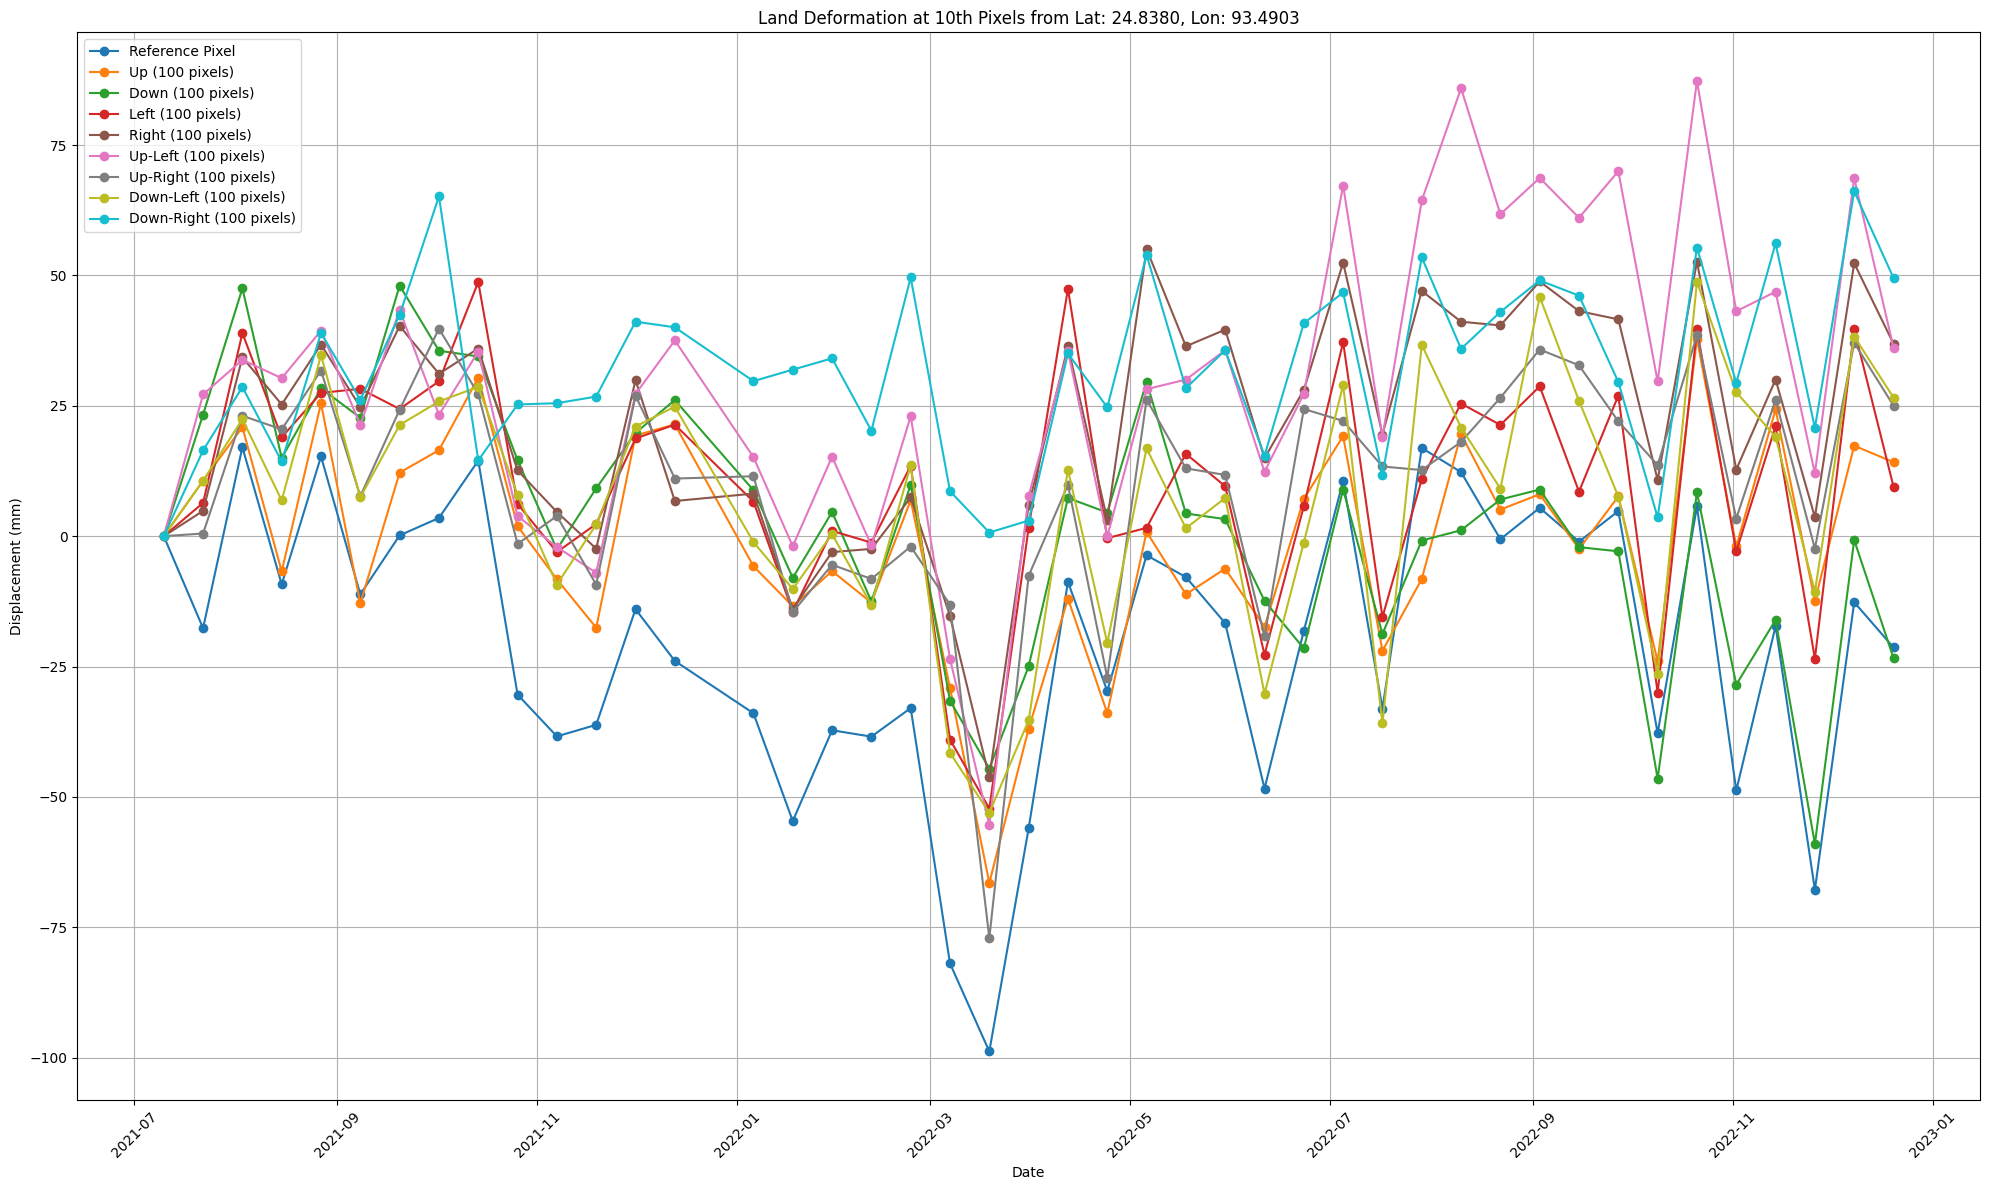

In [23]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
geometry_file = '/content/drive/MyDrive/mintpy_output/location2/geometryGeo.h5'
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Target coordinates (for title and context)
target_lat = 24.83804722
target_lon = 93.4902722

# Reference pixel (already calculated from target coordinates)
ref_y = 1518
ref_x = 859

# Get dataset dimensions from geometry file
with h5py.File(geometry_file, 'r') as f:
    LENGTH = int(f.attrs['LENGTH'])
    WIDTH = int(f.attrs['WIDTH'])
print(f"Dataset dimensions: LENGTH={LENGTH}, WIDTH={WIDTH}")

# Define the 10th pixel in each direction
step = 100  # Exactly 10 pixels away
pixels = [
    (ref_y, ref_x),           # Reference pixel
    (ref_y - step, ref_x),    # Up
    (ref_y + step, ref_x),    # Down
    (ref_y, ref_x - step),    # Left
    (ref_y, ref_x + step),    # Right
    (ref_y - step, ref_x - step),  # Up-left
    (ref_y - step, ref_x + step),  # Up-right
    (ref_y + step, ref_x - step),  # Down-left
    (ref_y + step, ref_x + step)   # Down-right
]

# Labels for each direction
labels = [
    "Reference Pixel",
    "Up (100 pixels)",
    "Down (100 pixels)",
    "Left (100 pixels)",
    "Right (100 pixels)",
    "Up-Left (100 pixels)",
    "Up-Right (100 pixels)",
    "Down-Left (100 pixels)",
    "Down-Right (100 pixels)"
]

# Filter pixels within bounds
valid_pixels = []
valid_labels = []
for (y, x), label in zip(pixels, labels):
    if 0 <= y < LENGTH and 0 <= x < WIDTH:
        valid_pixels.append((y, x))
        valid_labels.append(label)
    else:
        print(f"Pixel (y={y}, x={x}) is out of bounds and will be skipped.")

if not valid_pixels:
    raise ValueError("No valid pixels to plot.")

print(f"Pixels to plot: {list(zip(valid_pixels, valid_labels))}")

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    dates = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert dates to datetime
dates = [datetime.strptime(date, '%Y%m%d') for date in dates]

# Optional: Define date range (uncomment and adjust as needed)
# start_date = datetime(2023, 7, 19)
# end_date = datetime(2024, 6, 25)
# filtered_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]
# filtered_dates = [dates[i] for i in filtered_indices]
# if not filtered_dates:
#     print(f"No data available between {start_date.strftime('%Y-%m-%d')} and {end_date.strftime('%Y-%m-%d')}.")
#     print("Plotting all available data instead.")
#     filtered_dates = dates
#     filtered_indices = list(range(len(dates)))
# else:
#     print(f"Plotting data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# For now, plot all data
filtered_dates = dates
filtered_indices = list(range(len(dates)))

# Plot setup
plt.figure(figsize=(20, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(valid_pixels)))  # Distinct colors for each pixel

# Plot deformation for each pixel
for idx, ((pixel_y, pixel_x), label) in enumerate(zip(valid_pixels, valid_labels)):
    # Extract displacement for this pixel
    displacement = timeseries_data[:, pixel_y, pixel_x]
    filtered_displacement = displacement[filtered_indices]
    # Convert to millimeters
    displacement_mm = filtered_displacement * 1000
    # Plot
    plt.plot(filtered_dates, displacement_mm, marker='o', linestyle='-', color=colors[idx], label=label)

# Customize plot
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title(f'Land Deformation at 10th Pixels from Lat: {target_lat:.4f}, Lon: {target_lon:.4f}')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot to Google Drive
plt.savefig('/content/drive/MyDrive/mintpy_output/location2/deformation_10th_pixels_single_graph.png')
print("Plot saved to Google Drive as 'deformation_10th_pixels_single_graph.png'")

# Display the plot
plt.show()

In [24]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Reference pixel
ref_y = 1518
ref_x = 859

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    date_strs = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert date strings to datetime objects
dates = [datetime.strptime(date, '%Y%m%d') for date in date_strs]

# Define the date range for identification
start_date = datetime(2024, 6, 26)
end_date = datetime(2024, 7, 31)

# Find indices of dates within the range
date_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]

if not date_indices:
    print("No data available in the specified date range for identification.")
    print("Available dates in the dataset:")
    for date in dates:
        print(f"- {date.strftime('%Y-%m-%d')}")
    raise ValueError("No data points found in the specified date range.")

# Extract timeseries data for the specified date range
timeseries_range = timeseries_data[date_indices, :, :]

# Find the minimum value for each pixel within the date range
min_values = np.min(timeseries_range, axis=0)  # Shape: (LENGTH, WIDTH)

# Find the pixel with the smallest minimum value
min_value = np.min(min_values)
y_min, x_min = np.unravel_index(np.argmin(min_values), min_values.shape)
print(f"Pixel with most negative value in range: y={y_min}, x={x_min}, value={min_value} meters")

# Extract full time series for reference pixel and the identified pixel
ref_displacement = timeseries_data[:, ref_y, ref_x]
min_displacement = timeseries_data[:, y_min, x_min]

# Convert to millimeters
ref_displacement_mm = ref_displacement * 1000
min_displacement_mm = min_displacement * 1000

# Function to plot time series with highlighted range
def plot_timeseries(dates, displacement_mm, title, highlight_start, highlight_end):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, displacement_mm, marker='o', linestyle='-', color='b')
    plt.xlabel('Date')
    plt.ylabel('Displacement (mm)')
    plt.title(title)
    plt.grid(True)
    plt.xticks(rotation=45)

    # Highlight the specified date range with a shaded region
    plt.axvspan(highlight_start, highlight_end, color='yellow', alpha=0.3)

    plt.tight_layout()
    return plt

# Plot for reference pixel
plt_ref = plot_timeseries(dates, ref_displacement_mm, 'Reference Pixel (y=1518, x=859)', start_date, end_date)
plt_ref.savefig('/content/drive/MyDrive/mintpy_output/location2/reference_pixel_full.png')
print("Reference pixel plot saved as 'reference_pixel_full.png'")

# Plot for pixel with most negative value in range
plt_min = plot_timeseries(dates, min_displacement_mm, f'Pixel with Max Negative Value in Range (y={y_min}, x={x_min})', start_date, end_date)
plt_min.savefig('/content/drive/MyDrive/mintpy_output/location2/max_negative_pixel_full.png')
print("Max negative pixel plot saved as 'max_negative_pixel_full.png'")

# Show plots
plt_ref.show()
plt_min.show()

Mounted at /content/drive
No data available in the specified date range for identification.
Available dates in the dataset:
- 2021-07-10
- 2021-07-22
- 2021-08-03
- 2021-08-15
- 2021-08-27
- 2021-09-08
- 2021-09-20
- 2021-10-02
- 2021-10-14
- 2021-10-26
- 2021-11-07
- 2021-11-19
- 2021-12-01
- 2021-12-13
- 2022-01-06
- 2022-01-18
- 2022-01-30
- 2022-02-11
- 2022-02-23
- 2022-03-07
- 2022-03-19
- 2022-03-31
- 2022-04-12
- 2022-04-24
- 2022-05-06
- 2022-05-18
- 2022-05-30
- 2022-06-11
- 2022-06-23
- 2022-07-05
- 2022-07-17
- 2022-07-29
- 2022-08-10
- 2022-08-22
- 2022-09-03
- 2022-09-15
- 2022-09-27
- 2022-10-09
- 2022-10-21
- 2022-11-02
- 2022-11-14
- 2022-11-26
- 2022-12-08
- 2022-12-20


ValueError: No data points found in the specified date range.

In [25]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Reference pixel
ref_y = 1518
ref_x = 859

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    date_strs = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert date strings to datetime objects
dates = [datetime.strptime(date, '%Y%m%d') for date in date_strs]

# Define the date range for identification
start_date = datetime(2024, 6, 26)
end_date = datetime(2024, 7, 31)

# Find indices of dates within the range
date_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]

if not date_indices:
    print("No data available in the specified date range for identification.")
    print("Available dates in the dataset:")
    for date in dates:
        print(f"- {date.strftime('%Y-%m-%d')}")
    raise ValueError("No data points found in the specified date range.")

# Extract timeseries data for the specified date range
timeseries_range = timeseries_data[date_indices, :, :]

# Compute minimum values per pixel within the date range
min_values = np.min(timeseries_range, axis=0)  # Shape: (LENGTH, WIDTH)

# Find the top 5 pixels with the smallest minimum values
flat_indices = np.argpartition(min_values.ravel(), 4)[:5]  # Indices of 5 smallest
top5_y, top5_x = np.unravel_index(flat_indices, min_values.shape)

print("Top 5 pixels with most negative values in range:")
for i in range(5):
    y = top5_y[i]
    x = top5_x[i]
    min_val = min_values[y, x]
    print(f"Pixel {i+1}: y={y}, x={x}, min_value={min_val} meters")

# Extract full time series for reference pixel and top 5 pixels
ref_displacement = timeseries_data[:, ref_y, ref_x]
top5_displacements = [timeseries_data[:, y, x] for y, x in zip(top5_y, top5_x)]

# Convert to millimeters
ref_displacement_mm = ref_displacement * 1000
top5_displacements_mm = [disp * 1000 for disp in top5_displacements]

# Function to plot individual time series with highlighted range
def plot_individual_timeseries(dates, displacement_mm, title, highlight_start, highlight_end, save_path):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, displacement_mm, marker='o', linestyle='-', color='b')
    plt.xlabel('Date')
    plt.ylabel('Displacement (mm)')
    plt.title(title)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.axvspan(highlight_start, highlight_end, color='yellow', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Plot saved as '{save_path}'")
    plt.show()

# Plot all pixels on one graph
plt.figure(figsize=(14, 8))
plt.plot(dates, ref_displacement_mm, marker='o', linestyle='-', color='b', label='Reference Pixel (y=1518, x=859)')
colors = ['r', 'g', 'm', 'c', 'y']
for i in range(5):
    y = top5_y[i]
    x = top5_x[i]
    label = f'Top {i+1} Negative: y={y}, x={x}'
    plt.plot(dates, top5_displacements_mm[i], marker='o', linestyle='-', color=colors[i], label=label)
plt.axvspan(start_date, end_date, color='yellow', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title('Land Deformation: Reference vs. Top 5 Negative Pixels')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mintpy_output/location2/deformation_ref_vs_top5.png')
print("Combined plot saved as 'deformation_ref_vs_top5.png'")
plt.show()

# Plot individual graphs
plot_individual_timeseries(
    dates,
    ref_displacement_mm,
    'Reference Pixel (y=1518, x=859)',
    start_date,
    end_date,
    '/content/drive/MyDrive/mintpy_output/location2/reference_pixel.png'
)
for i in range(5):
    y = top5_y[i]
    x = top5_x[i]
    title = f'Top {i+1} Negative Pixel (y={y}, x={x})'
    save_path = f'/content/drive/MyDrive/mintpy_output/location2/top_{i+1}_negative_y{y}_x{x}.png'
    plot_individual_timeseries(
        dates,
        top5_displacements_mm[i],
        title,
        start_date,
        end_date,
        save_path
    )

Mounted at /content/drive
No data available in the specified date range for identification.
Available dates in the dataset:
- 2021-07-10
- 2021-07-22
- 2021-08-03
- 2021-08-15
- 2021-08-27
- 2021-09-08
- 2021-09-20
- 2021-10-02
- 2021-10-14
- 2021-10-26
- 2021-11-07
- 2021-11-19
- 2021-12-01
- 2021-12-13
- 2022-01-06
- 2022-01-18
- 2022-01-30
- 2022-02-11
- 2022-02-23
- 2022-03-07
- 2022-03-19
- 2022-03-31
- 2022-04-12
- 2022-04-24
- 2022-05-06
- 2022-05-18
- 2022-05-30
- 2022-06-11
- 2022-06-23
- 2022-07-05
- 2022-07-17
- 2022-07-29
- 2022-08-10
- 2022-08-22
- 2022-09-03
- 2022-09-15
- 2022-09-27
- 2022-10-09
- 2022-10-21
- 2022-11-02
- 2022-11-14
- 2022-11-26
- 2022-12-08
- 2022-12-20


ValueError: No data points found in the specified date range.

Mounted at /content/drive
Pixel with maximum negative value in range: y=751, x=495, value=-266.90 mm
Plot saved to Google Drive as 'deformation_ref_vs_max_negative.png'


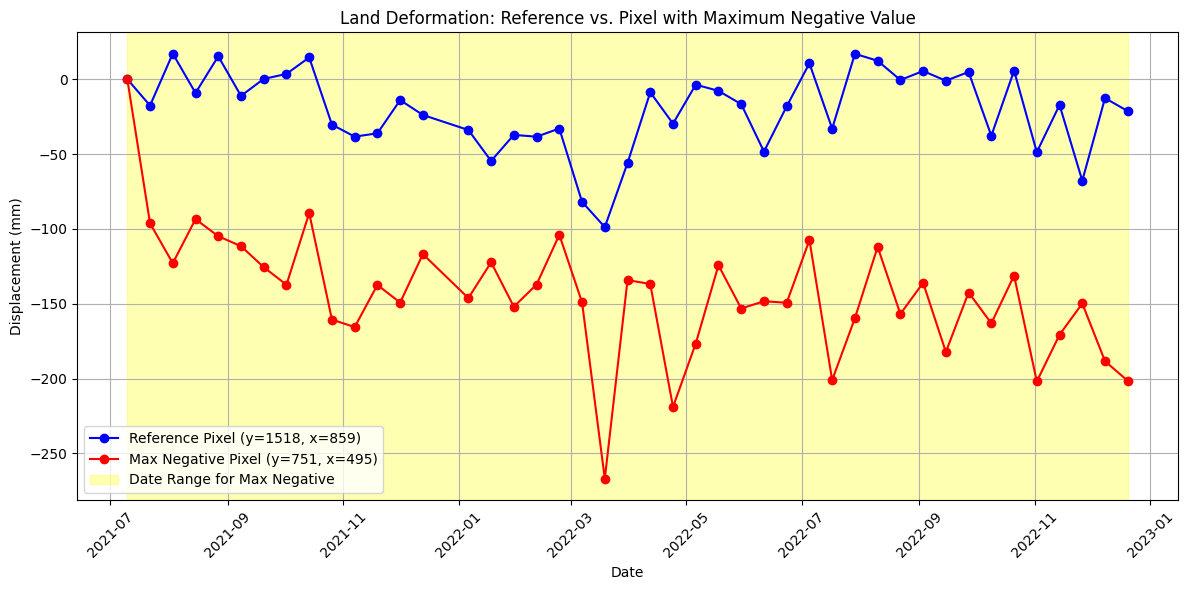

In [26]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Reference pixel
ref_y = 1518
ref_x = 859

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    date_strs = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert date strings to datetime objects
dates = [datetime.strptime(date, '%Y%m%d') for date in date_strs]

# Define the date range for identifying the maximum negative value
start_date = datetime(2021, 7, 10)
end_date = datetime(2022, 12, 20)

# Find indices of dates within the range
date_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]

if not date_indices:
    print("No data available in the specified date range for identification.")
    print("Available dates in the dataset:")
    for date in dates:
        print(f"- {date.strftime('%Y-%m-%d')}")
    raise ValueError("No data points found in the specified date range.")

# Extract timeseries data for the specified date range
timeseries_range = timeseries_data[date_indices, :, :]

# Find the minimum value for each pixel within the date range
min_values = np.min(timeseries_range, axis=0)  # Shape: (LENGTH, WIDTH)

# Find the pixel with the smallest minimum value (maximum negative)
min_value = np.min(min_values)
y_min, x_min = np.unravel_index(np.argmin(min_values), min_values.shape)
print(f"Pixel with maximum negative value in range: y={y_min}, x={x_min}, value={min_value*1000:.2f} mm")

# Extract full time series for reference pixel and the identified pixel
ref_displacement = timeseries_data[:, ref_y, ref_x]
min_displacement = timeseries_data[:, y_min, x_min]

# Convert to millimeters
ref_displacement_mm = ref_displacement * 1000
min_displacement_mm = min_displacement * 1000

# Plot setup
plt.figure(figsize=(12, 6))

# Plot reference pixel
plt.plot(dates, ref_displacement_mm, marker='o', linestyle='-', color='b', label=f'Reference Pixel (y={ref_y}, x={ref_x})')

# Plot pixel with maximum negative value
plt.plot(dates, min_displacement_mm, marker='o', linestyle='-', color='r', label=f'Max Negative Pixel (y={y_min}, x={x_min})')

# Highlight the date range used for identification
plt.axvspan(start_date, end_date, color='yellow', alpha=0.3, label='Date Range for Max Negative')

# Customize plot
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title('Land Deformation: Reference vs. Pixel with Maximum Negative Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot to Google Drive
plt.savefig('/content/drive/MyDrive/mintpy_output/location2/deformation_ref_vs_max_negative.png')
print("Plot saved to Google Drive as 'deformation_ref_vs_max_negative.png'")

# Display the plot
plt.show()

Mounted at /content/drive
Top 5 pixels with maximum negative values in range:
Top 1: y=751, x=495, value=-266.90 mm
Top 2: y=760, x=475, value=-255.25 mm
Top 3: y=750, x=496, value=-249.71 mm
Top 4: y=811, x=502, value=-249.22 mm
Top 5: y=759, x=469, value=-245.24 mm
Plot saved to Google Drive as 'deformation_ref_subref_top5_negative.png'


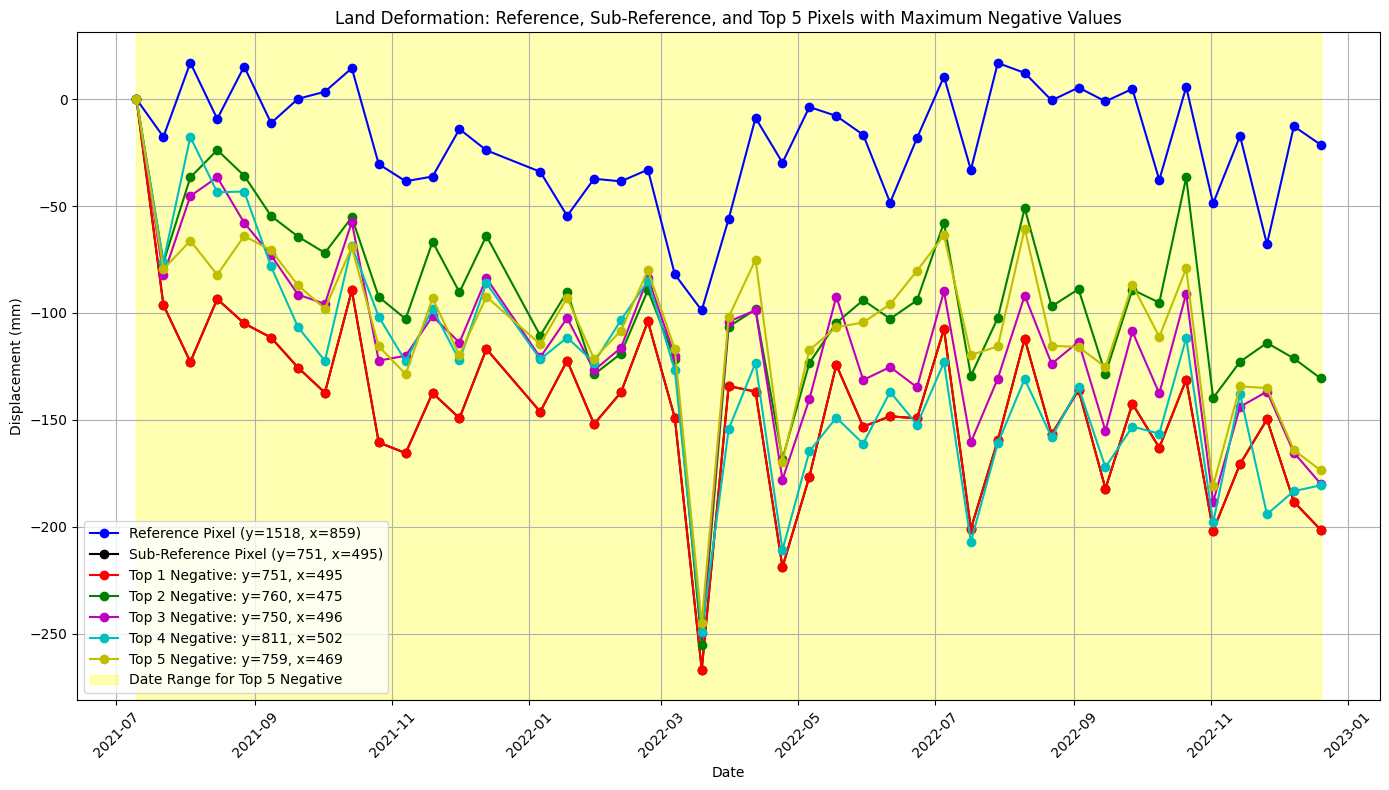

In [27]:
from google.colab import drive
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# File paths
timeseries_file = '/content/drive/MyDrive/mintpy_output/location2/timeseries_ERA5_demErr.h5'

# Reference pixel
ref_y = 1518
ref_x = 859

# Sub-reference pixel
subref_y = 751
subref_x = 495

# Load timeseries data
with h5py.File(timeseries_file, 'r') as f:
    date_strs = [date.decode('utf-8') for date in f['date'][:]]
    timeseries_data = f['timeseries'][:]

# Convert date strings to datetime objects
dates = [datetime.strptime(date, '%Y%m%d') for date in date_strs]

# Define the date range for identifying the top 5 negative values
start_date = datetime(2021, 7, 10)
end_date = datetime(2022, 12, 20)

# Find indices of dates within the range
date_indices = [i for i, date in enumerate(dates) if start_date <= date <= end_date]

if not date_indices:
    print("No data available in the specified date range for identification.")
    print("Available dates in the dataset:")
    for date in dates:
        print(f"- {date.strftime('%Y-%m-%d')}")
    raise ValueError("No data points found in the specified date range.")

# Extract timeseries data for the specified date range
timeseries_range = timeseries_data[date_indices, :, :]

# Compute minimum values per pixel within the date range
min_values = np.min(timeseries_range, axis=0)  # Shape: (LENGTH, WIDTH)

# Find the top 5 pixels with the smallest minimum values
flat_indices = np.argpartition(min_values.ravel(), 4)[:5]  # Indices of 5 smallest values
top5_y, top5_x = np.unravel_index(flat_indices, min_values.shape)

# Sort the top 5 by their minimum values (most negative first)
top5_coords = list(zip(top5_y, top5_x))
top5_values = [min_values[y, x] for y, x in top5_coords]
sorted_indices = np.argsort(top5_values)
top5_coords = [top5_coords[i] for i in sorted_indices]
top5_values = [top5_values[i] for i in sorted_indices]

# Print the top 5 pixels with their minimum values
print("Top 5 pixels with maximum negative values in range:")
for i, ((y, x), value) in enumerate(zip(top5_coords, top5_values)):
    print(f"Top {i+1}: y={y}, x={x}, value={value*1000:.2f} mm")

# Extract full time series for reference pixel, sub-reference pixel, and top 5 pixels
ref_displacement = timeseries_data[:, ref_y, ref_x]
subref_displacement = timeseries_data[:, subref_y, subref_x]
top5_displacements = [timeseries_data[:, y, x] for y, x in top5_coords]

# Convert to millimeters
ref_displacement_mm = ref_displacement * 1000
subref_displacement_mm = subref_displacement * 1000
top5_displacements_mm = [disp * 1000 for disp in top5_displacements]

# Plot setup
plt.figure(figsize=(14, 8))
colors = ['r', 'g', 'm', 'c', 'y']  # Colors for top 5 pixels

# Plot reference pixel
plt.plot(dates, ref_displacement_mm, marker='o', linestyle='-', color='b', label=f'Reference Pixel (y={ref_y}, x={ref_x})')

# Plot sub-reference pixel
plt.plot(dates, subref_displacement_mm, marker='o', linestyle='-', color='k', label=f'Sub-Reference Pixel (y={subref_y}, x={subref_x})')

# Plot top 5 pixels
for i, (displacement_mm, (y, x)) in enumerate(zip(top5_displacements_mm, top5_coords)):
    label = f'Top {i+1} Negative: y={y}, x={x}'
    plt.plot(dates, displacement_mm, marker='o', linestyle='-', color=colors[i], label=label)

# Highlight the date range used for identification
plt.axvspan(start_date, end_date, color='yellow', alpha=0.3, label='Date Range for Top 5 Negative')

# Customize plot
plt.xlabel('Date')
plt.ylabel('Displacement (mm)')
plt.title('Land Deformation: Reference, Sub-Reference, and Top 5 Pixels with Maximum Negative Values')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot to Google Drive
plt.savefig('/content/drive/MyDrive/mintpy_output/location2/deformation_ref_subref_top5_negative.png')
print("Plot saved to Google Drive as 'deformation_ref_subref_top5_negative.png'")

# Display the plot
plt.show()